In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [19]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [3]:
data = load_diabetes()

In [4]:
df = pd.DataFrame(data.data , columns = data.feature_names)
df['target'] = data.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
X_train , X_test , y_train , y_test = train_test_split(data.data , data.target , test_size = 0.2 , random_state = 2)

<h2 style = "color:green;">Effects of Alpha on coef and r2 score</h2>

In [20]:
coefs = [] 
r2_scores = [] 

# Do Lasso for different different values of Alpha 
alphas = [0 , 0.1 , 1 , 10]
for alpha in alphas: 
    reg = Lasso(alpha = alpha)
    reg.fit(X_train , y_train)

    y_pred = reg.predict(X_test)
    r2 = r2_score(y_test , y_pred)

    r2_scores.append(r2)
    coefs.append(reg.coef_)

In [12]:
r2_scores

[0.4399338662581874,
 0.4334618007658305,
 0.3256808253711555,
 -0.012517603619692785]

In [13]:
coefs

[array([  -9.15865318, -205.45432152,  516.69374477,  340.61999899,
        -895.55198905,  561.22066898,  153.89310382,  126.73139522,
         861.12699676,   52.42112237]),
 array([   0.        , -113.96992829,  526.74439601,  292.62847198,
         -82.69368149,   -0.        , -152.68533835,    0.        ,
         551.08029055,    7.17099207]),
 array([  0.        ,   0.        , 363.88574216,  27.27316304,
          0.        ,   0.        ,  -0.        ,   0.        ,
        336.137262  ,   0.        ]),
 array([ 0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0.])]

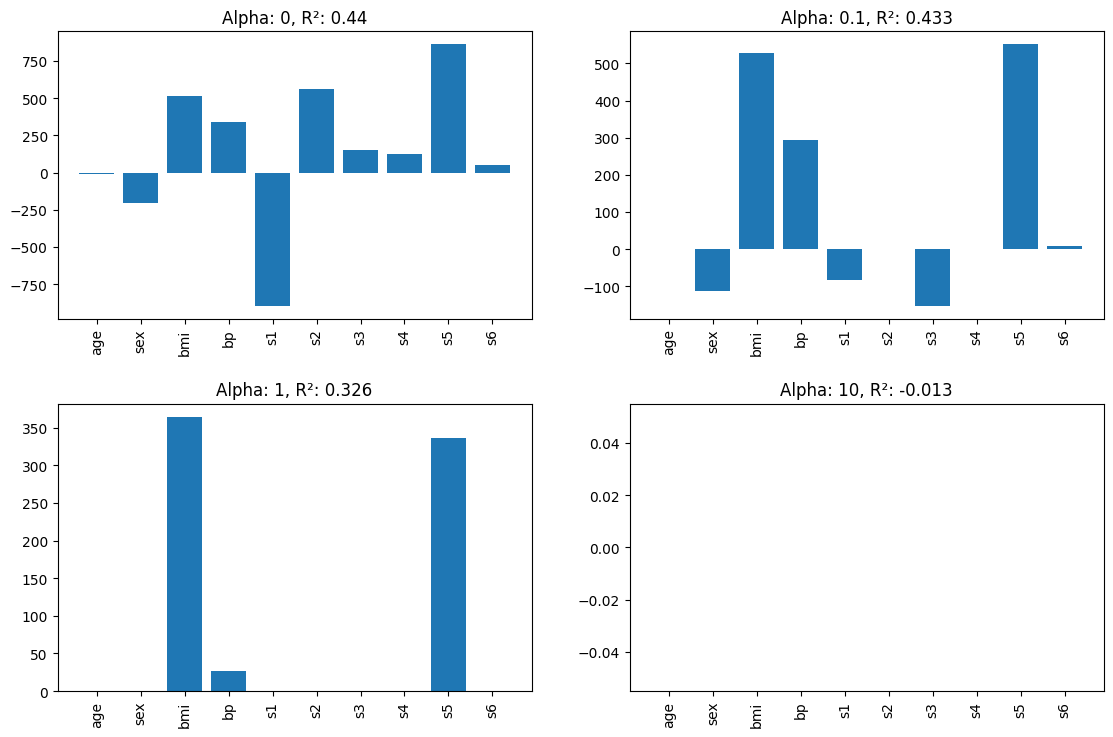

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.tight_layout(pad=4.0)


for index , axis in enumerate(ax.flat): 
    axis.bar(data.feature_names , coefs[index]) 
    axis.set_title(f"Alpha: {alphas[index]}, R²: {np.round(r2_scores[index] , 3)}")
    axis.tick_params(axis='x', labelrotation=90)
    
plt.show()

As We increasing the values of alpha Lasso is shrinking the coeffs toward zero Also making some coef to zero(doing feature selection -> set coef = 0 for unimportant feature) And by doing this for very high value it goes to under-fitting cause removes all features

<h2 style = "color:green;">2. Higher Coefficients are affected more</h2>

- Coeff with higher value shrinks more as we increase the value of `alpha`
- Higher coeffs shrinks more.
- Lower coeffs shrinks less.

In [23]:
alphas = [0 , 0.0001 , 0.001 , 0.01 , 0.1 , 1 , 5 , 10 , 50 , 100 , 500 , 1000]

coefs = []

for alpha in alphas: 
    model = Lasso(alpha = alpha)
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)
    coefs.append(model.coef_)
    print(f"Alpha: {alpha}")
    print(f"r2_score: {r2_score(y_test , y_pred)}")
    print("Coeff: " , model.coef_)
    print("---------------------------------------------")

Alpha: 0
r2_score: 0.4399338662581874
Coeff:  [  -9.15865318 -205.45432152  516.69374477  340.61999899 -895.55198905
  561.22066898  153.89310382  126.73139522  861.12699676   52.42112237]
---------------------------------------------
Alpha: 0.0001
r2_score: 0.4399732201362009
Coeff:  [  -9.06906443 -205.32940644  516.78941848  340.53237885 -888.66090377
  555.95858353  150.5936554   125.45014323  858.64554075   52.3802936 ]
---------------------------------------------
Alpha: 0.001
r2_score: 0.44030096069159674
Coeff:  [  -8.26276976 -204.20536429  517.65007282  339.7439007  -826.6636033
  508.61739504  120.90860746  113.92177296  836.32075334   52.01284899]
---------------------------------------------
Alpha: 0.01
r2_score: 0.44111855963110613
Coeff:  [  -1.35972089 -192.93718018  526.35651446  332.6411011  -430.22697505
  191.29547987  -44.03491271   68.98898658  688.39602778   47.94061621]
---------------------------------------------
Alpha: 0.1
r2_score: 0.4334618007658305
Coeff: 

- As we are increasing the value of alpha Model tends to move towards under-fitting

In [26]:
input_array = np.array(coefs)

coef_df = pd.DataFrame(input_array , columns = data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.551989,561.220669,153.893104,126.731395,861.126997,52.421122
0.0001,-9.069064,-205.329406,516.789418,340.532379,-888.660904,555.958584,150.593655,125.450143,858.645541,52.380294
0.0010,-8.262770,-204.205364,517.650073,339.743901,-826.663603,508.617395,120.908607,113.921773,836.320753,52.012849
0.0100,-1.359721,-192.937180,526.356514,332.641101,-430.226975,191.295480,-44.034913,68.988987,688.396028,47.940616
0.1000,0.000000,-113.969928,526.744396,292.628472,-82.693681,-0.000000,-152.685338,0.000000,551.080291,7.170992
1.0000,0.000000,0.000000,363.885742,27.273163,0.000000,0.000000,-0.000000,0.000000,336.137262,0.000000
5.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
10.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
50.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


<h2 style = "color:green;">Impact on Bias and Variance</h2>

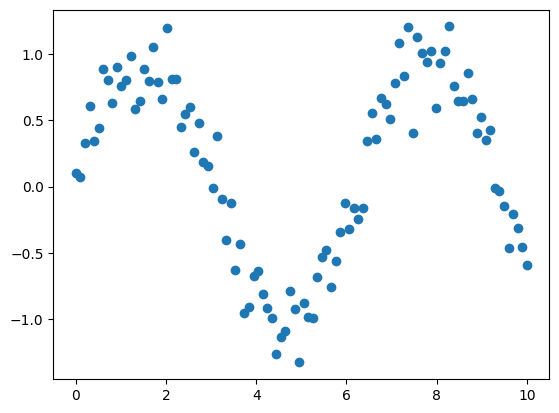

In [37]:
np.random.seed(42) 
m = 100

X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])  # 0.2 is noise level

plt.scatter(X , y) 
plt.show()

In [40]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2) 

In [41]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 10)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [42]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0 , 30 , 100)

loss = [] # Total error
bias = []
variance = []

for alpha in alphas: 
    model = Lasso(alpha = alpha)

    l , b , v = bias_variance_decomp(
        model , X_train , y_train , X_test , y_test , loss = 'mse' , random_seed = 123 
    )
    loss.append(l)
    bias.append(b)
    variance.append(v)

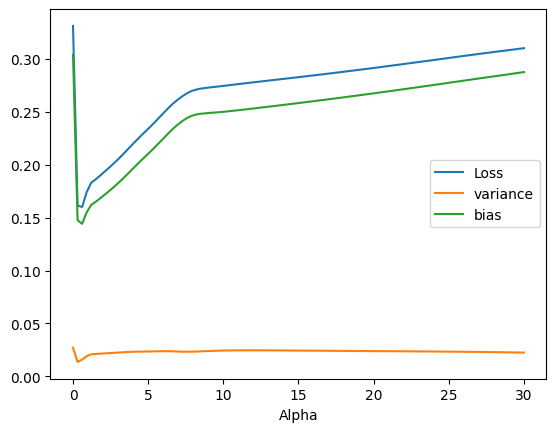

In [44]:
plt.plot(alphas , loss , label = 'Loss')
plt.plot(alphas , variance , label = 'variance') 
plt.plot(alphas , bias , label = 'bias') 
plt.xlabel("Alpha")
plt.legend()
plt.show()

## Effect of Lasso in Loss Function

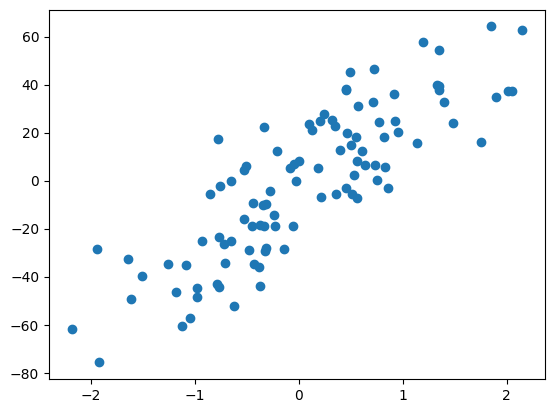

[27.82809103]
-2.29474455867698


In [45]:
from sklearn.datasets import make_regression

X , y = make_regression(n_samples = 100 , n_features = 1 , n_informative = 1 , n_targets = 1 , noise = 20 , random_state = 13)

plt.scatter(X , y) 
plt.show()

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X , y)
print(lr.coef_)
print(lr.intercept_)

In [46]:
def cal_loss(m , alpha): 
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*abs(m) 

In [47]:
def predict(m): 
    return m*X - 2.29

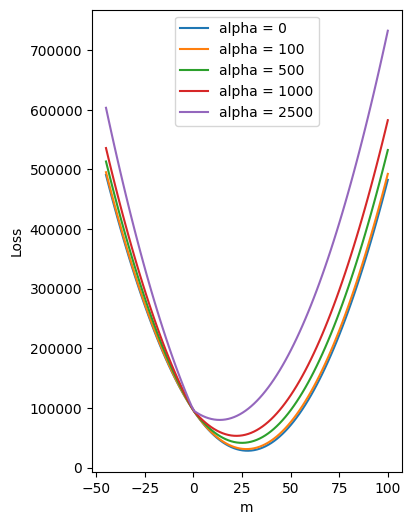

In [48]:
m = np.linspace(-45 , 100 , 100)

plt.figure(figsize = (4 , 6))

for j in [0 , 100 , 500 , 1000 , 2500]:
    loss = [] 
    for i in range(m.shape[0]): 
        loss_i = cal_loss(m[i] , j) 
        loss.append(loss_i)
    plt.plot(m , loss , label = 'alpha = {}'.format(j))

plt.legend()
plt.xlabel("m")
plt.ylabel("Loss")
plt.show()